In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [48]:
df = pd.read_csv('/content/train.csv')

df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [49]:
df.shape

(913000, 4)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [51]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [52]:
print(df['date'].min(), df['date'].max())

2013-01-01 2017-12-31


In [53]:
print(df.isnull().sum())
print(df.duplicated(["store","date","item"]).sum())

date     0
store    0
item     0
sales    0
dtype: int64
0


In [54]:
print(df.groupby(["store","item"]).size().describe())

count     500.0
mean     1826.0
std         0.0
min      1826.0
25%      1826.0
50%      1826.0
75%      1826.0
max      1826.0
dtype: float64


<Axes: xlabel='date'>

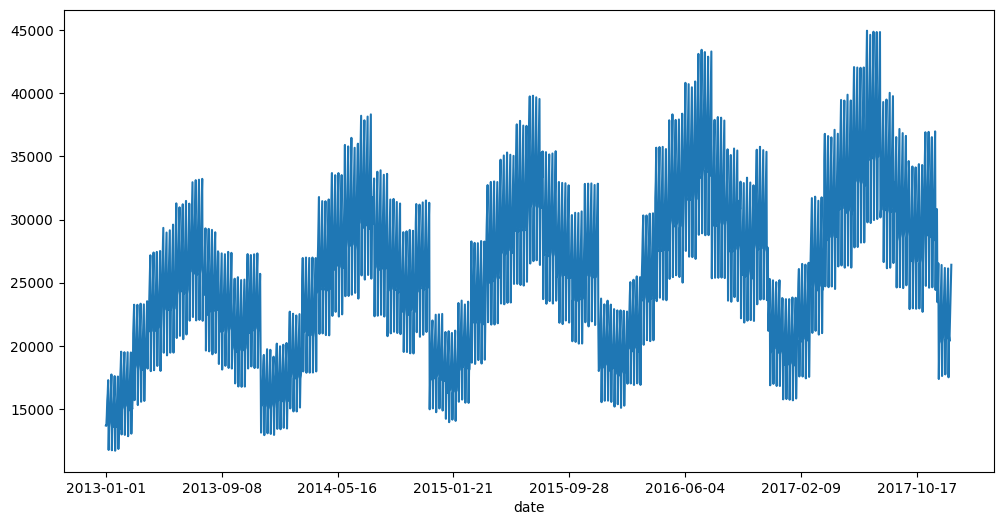

In [55]:
daily = df.groupby("date")["sales"].sum()
daily.plot(figsize=(12,6))

In [56]:
df["date"]= pd.to_datetime(df["date"])

<Axes: xlabel='dow_name'>

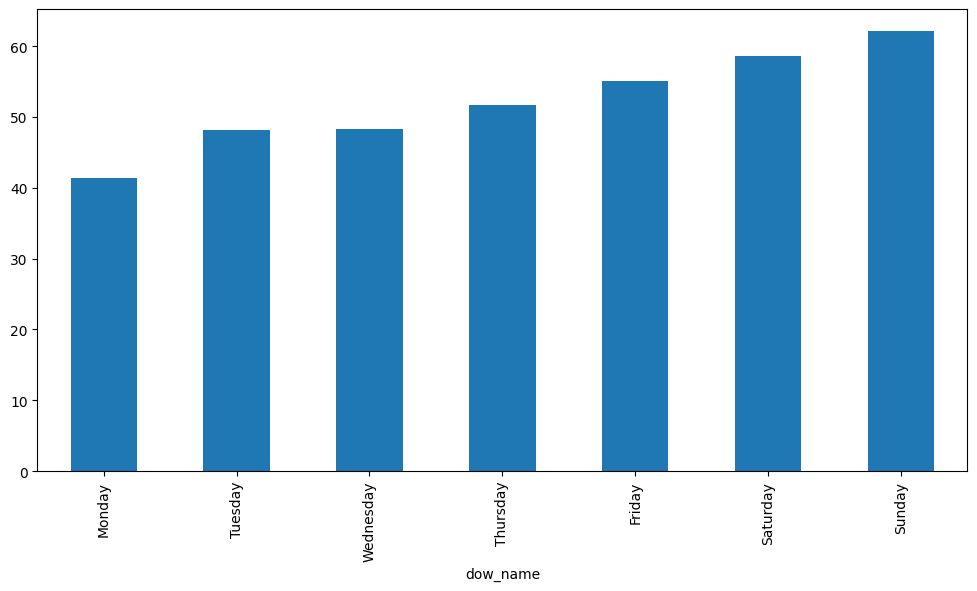

In [57]:
df["dow"] = df["date"].dt.dayofweek
df["dow_name"] = df["date"].dt.day_name()
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
avg = df.groupby("dow_name")["sales"].mean().reindex(order)
avg.plot(kind="bar",figsize=(12,6))


<Axes: xlabel='month_name'>

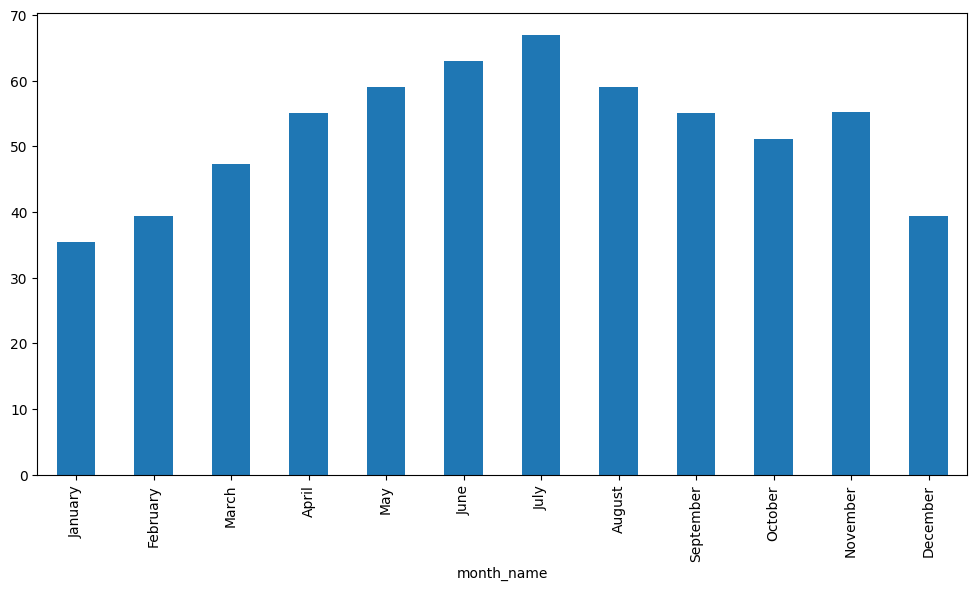

In [58]:
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
avg = df.groupby("month_name")["sales"].mean().reindex(order)
avg.plot(kind="bar",figsize=(12,6))

In [59]:
print(df.groupby("dow")["sales"].mean())
print(df.groupby("month")["sales"].mean())

dow
0    41.429638
1    48.225908
2    48.368506
3    51.723218
4    55.157249
5    58.662697
6    62.143333
Name: sales, dtype: float64
month
1     35.524503
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64


In [60]:
avg_dow = df.groupby("dow_name")["sales"].mean()
hi, lo = avg_dow.max(), avg_dow.min()
print(avg_dow.idxmax(), avg_dow.idxmin())
print(f"diff: {(hi - lo) / lo * 100:.1f}%")


avg_m = df.groupby("month_name")["sales"].mean()
hi, lo = avg_m.max(), avg_m.min()
print(avg_m.idxmax(), avg_m.idxmin())
print(f"diff: {(hi - lo) / lo * 100:.1f}%")

Sunday Monday
diff: 50.0%
July January
diff: 88.6%


date
2013    43.513660
2014    50.057436
2015    52.256915
2016    56.596503
2017    58.815014
Name: sales, dtype: float64


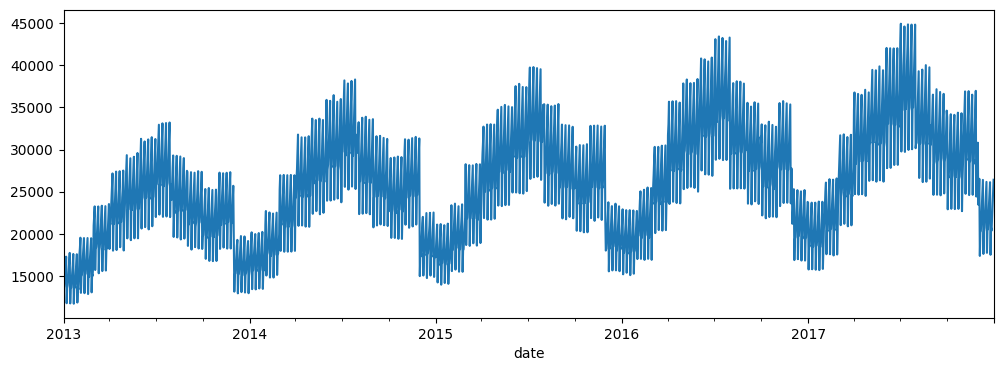

In [61]:
daily = df.groupby("date")["sales"].sum()
daily.plot(figsize=(12,4))

yearly = df.groupby(df["date"].dt.year)["sales"].mean()
print(yearly)

In [62]:
yearly = df.groupby(df["date"].dt.year)["sales"].mean()
print(yearly)
print(yearly.pct_change()*100)

date
2013    43.513660
2014    50.057436
2015    52.256915
2016    56.596503
2017    58.815014
Name: sales, dtype: float64
date
2013          NaN
2014    15.038439
2015     4.393912
2016     8.304332
2017     3.919873
Name: sales, dtype: float64


In [63]:
test = df[df['date'] >= "2017-10-01"].copy()
ly = df[["date","sales","item","store"]].copy()
ly["date"] = ly["date"] + pd.Timedelta(days=364)
test = test.merge(ly, on=["date","store","item"], how="left",
                  suffixes=("","_pred"))

err = r = test["sales"] - test["sales_pred"]
print("MAE :", err.abs().mean())
print("WAPE:", err.abs().sum() / test["sales"].sum() * 100)
print("Bias:", (test["sales_pred"].sum() - test["sales"].sum()) / test["sales"].sum() * 100)

MAE : 8.353695652173913
WAPE: 15.278110757655455
Bias: -4.126087850230223


In [64]:
df = df.sort_values(["store","date","item"])
g = df.groupby(["store","item"])["sales"]


df["lag_14"]= g.shift(14)
df["lag_28"]= g.shift(28)
df["lag_364"]= g.shift(364)

df["roll_mean_28"]= g.shift(14).rolling(28).mean().reset_index( drop=True)

In [65]:
df["day"] = df["date"].dt.day
df["year"] = df["date"].dt.year

In [66]:
from xgboost import XGBRegressor

features = ["store", "item", "dow", "month", "day", "year",
            "lag_14", "lag_28", "lag_364", "roll_mean_28"]

train = df[df["date"] < "2017-10-01"]
test = df[df["date"] >= "2017-10-01"].copy()

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    random_state=42,
)
model.fit(train[features], train["sales"])

test["pred"] = model.predict(test[features])
err = test["sales"] - test["pred"]

print("MAE :", err.abs().mean())
print("WAPE:", err.abs().sum() / test["sales"].sum() * 100)
print("Bias:", (test["pred"].sum() - test["sales"].sum()) / test["sales"].sum() * 100)

MAE : 6.303693007925283
WAPE: 11.52885189590047
Bias: -0.111632746453814


In [67]:
def run_window(cutoff, days=90):
    cutoff = pd.Timestamp(cutoff)
    tr = df[df["date"] < cutoff]
    te = df[(df["date"] >= cutoff) &
            (df["date"] < cutoff + pd.Timedelta(days=days))].copy()

    m = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                     subsample=0.8, colsample_bytree=0.8,
                     tree_method="hist", random_state=42)
    m.fit(tr[features], tr["sales"])
    te["pred"] = m.predict(te[features])

    base = te["lag_364"]
    wape = lambda p: (te["sales"] - p).abs().sum() / te["sales"].sum() * 100
    bias = lambda p: (p.sum() - te["sales"].sum()) / te["sales"].sum() * 100
    return cutoff.date(), wape(base), wape(te["pred"]), bias(te["pred"])

for c in ["2016-10-01", "2017-01-01", "2017-04-01", "2017-07-01", "2017-10-01"]:
    print(run_window(c))

(datetime.date(2016, 10, 1), np.float64(16.56468870447242), np.float64(11.740585760300995), np.float64(-0.12651702405319826))
(datetime.date(2017, 1, 1), np.float64(16.42531903973237), np.float64(12.538906531776858), np.float64(0.2216517200930268))
(datetime.date(2017, 4, 1), np.float64(13.677213515947493), np.float64(10.624850427352227), np.float64(-1.5599148306489141))
(datetime.date(2017, 7, 1), np.float64(13.527779299978862), np.float64(10.297692258552667), np.float64(-0.9479126708888175))
(datetime.date(2017, 10, 1), np.float64(15.248122888642923), np.float64(11.506490672455659), np.float64(-0.10070993145027578))


In [68]:
def wape_by(col):
    t = test.assign(abs_err=(test["sales"] - test["pred"]).abs())
    g = t.groupby(col)
    return (g["abs_err"].sum() / g["sales"].sum() * 100).sort_values()

print(wape_by("store"))
print(wape_by("dow"))
w_item = wape_by("item")
print(w_item.head(5))
print(w_item.tail(5))

print(pd.Series(model.feature_importances_, index=features).sort_values())

store
2     10.232972
8     10.475121
10    10.759755
3     10.923773
9     11.382814
4     11.408376
1     12.020123
6     13.249755
5     13.519475
7     13.725570
dtype: float64
dow
5    10.756699
6    10.860980
4    11.167159
3    11.456914
2    12.035043
1    12.209158
0    12.839685
dtype: float64
item
15    8.967138
22    9.058827
18    9.100485
28    9.194741
13    9.372316
dtype: float64
item
4     17.657380
47    17.744300
27    18.273652
5     18.360955
41    18.705745
dtype: float64
roll_mean_28    0.001555
store           0.004155
dow             0.004181
year            0.005173
item            0.005710
day             0.005756
month           0.024529
lag_364         0.125832
lag_28          0.260070
lag_14          0.563040
dtype: float32


In [69]:
vol = test.groupby("item")["sales"].mean()
res = pd.DataFrame({"wape": wape_by("item"), "avg_sales": vol})
print(res.sort_values("wape").tail(5))
print(res.corr())

           wape  avg_sales
item                      
4     17.657380  22.969565
47    17.744300  22.969565
27    18.273652  22.792391
5     18.360955  19.317391
41    18.705745  22.789130
               wape  avg_sales
wape       1.000000  -0.964883
avg_sales -0.964883   1.000000


In [70]:
g = df.groupby(["store", "item"])["sales"]
df["lag_21"] = g.shift(21)
df["lag_35"] = g.shift(35)
df["lag_42"] = g.shift(42)
df["dow_mean_4w"] = df[["lag_14", "lag_21", "lag_28", "lag_35"]].mean(axis=1)
df["roll_std_28"] = g.transform(lambda s: s.shift(14).rolling(28).std())

features2 = features + ["lag_21", "lag_35", "lag_42", "dow_mean_4w", "roll_std_28"]

train = df[df["date"] < "2017-10-01"]
test = df[df["date"] >= "2017-10-01"].copy()

model2 = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                      subsample=0.8, colsample_bytree=0.8,
                      tree_method="hist", random_state=42)
model2.fit(train[features2], train["sales"])

test["pred"] = model2.predict(test[features2])
err = test["sales"] - test["pred"]
print("MAE :", err.abs().mean())
print("WAPE:", err.abs().sum() / test["sales"].sum() * 100)
print("Bias:", (test["pred"].sum() - test["sales"].sum()) / test["sales"].sum() * 100)

MAE : 6.116407798518305
WAPE: 11.186325151842484
Bias: -0.10054998336094581


In [71]:
def impact(y, p):
    under = (y - p).clip(lower=0).sum()
    over  = (p - y).clip(lower=0).sum()
    return under, over, y.sum()

for name, p in [("Baseline", test["lag_364"]), ("Model", test["pred"])]:
    u, o, tot = impact(test["sales"], p)
    print(name, f"| Lost: {u/tot*100:.1f}% | Excess: {o/tot*100:.1f}%")

Baseline | Lost: 9.7% | Excess: 5.6%
Model | Lost: 5.6% | Excess: 5.5%


In [72]:
def run_window2(cutoff, days=90):
    cutoff = pd.Timestamp(cutoff)
    tr = df[df["date"] < cutoff]
    te = df[(df["date"] >= cutoff) &
            (df["date"] < cutoff + pd.Timedelta(days=days))].copy()

    m = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                     subsample=0.8, colsample_bytree=0.8,
                     tree_method="hist", random_state=42)
    m.fit(tr[features2], tr["sales"])
    te["pred"] = m.predict(te[features2])

    wape = (te["sales"] - te["pred"]).abs().sum() / te["sales"].sum() * 100
    bias = (te["pred"].sum() - te["sales"].sum()) / te["sales"].sum() * 100
    return cutoff.date(), round(wape, 2), round(bias, 2)

for c in ["2016-10-01", "2017-01-01", "2017-04-01", "2017-07-01", "2017-10-01"]:
    print(run_window2(c))

(datetime.date(2016, 10, 1), np.float64(11.33), np.float64(-0.23))
(datetime.date(2017, 1, 1), np.float64(12.24), np.float64(1.01))
(datetime.date(2017, 4, 1), np.float64(10.27), np.float64(-0.88))
(datetime.date(2017, 7, 1), np.float64(10.0), np.float64(-0.38))
(datetime.date(2017, 10, 1), np.float64(11.17), np.float64(-0.07))


In [73]:
model2.save_model("model.json")

last = df["date"].max()
hist = df[df["date"] >= last - pd.Timedelta(days=400)]
hist[["date","store","item","sales"]].to_csv("history.csv", index=False)

from google.colab import files
files.download("model.json"); files.download("history.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>